In [2]:
!pip install emoji
import pandas as pd

from google.colab import drive
drive.mount('/content/drive')

# read sample data from csv
file_path = '/content/drive/My Drive/notebooks/Yelp JSON/yelp_dataset (Unzipped Files)/yelp_review_data_binned.csv'
df_review_data_binned = pd.read_csv(file_path)

df_review_data_binned.info()

df_review_data_binned = df_review_data_binned.dropna(subset=["text", "stars_binned"])

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 608.4/608.4 kB 9.9 MB/s eta 0:00:00
Mounted at /content/drive
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 144209 entries, 0 to 144208
Data columns (total 11 columns):
 #   Column          Non-Null Count   Dtype  
---  ------          --------------   -----  
 0   review_id       144209 non-null  object 
 1   user_id         144209 non-null  object 
 2   business_id     144209 non-null  object 
 3   stars           144209 non-null  int64  
 4   useful          144209 non-null  int64  
 5   funny           144209 non-null  int64  
 6   cool            144209 non-null  int64  
 7   text            144209 non-null  object 
 8   date            144209 non-null  object 
 9   stars_business  144209 non-null  float64
 10  stars_binned    144209 non-null  int64  
dtypes: float64(1), int64(5), object(5)
memory usage: 12.1+ MB


In [3]:
# Pre-processing
import emoji
import re
import nltk
import unicodedata
from nltk.corpus import stopwords
from nltk.tokenize import word_tokenize

df_review_data_binned = df_review_data_binned.dropna(subset=['stars_binned'])
df_review_data_binned = df_review_data_binned.dropna(subset=['text'])
print(df_review_data_binned.shape)


# Identify if there are any emoji characters

def clean_text(text):
  if text is None:
    return ""
  text = emoji.replace_emoji(text, replace='')
  # convert to lower case
  text = text.lower()
  # remove strings that start with http
  text = re.sub(r'http\S+', '', text)
  # remove HTML tags
  text = re.sub(r'<.*?>', '', text)
  # remove special characters
  text = re.sub(r'www\S+', '', text)
  # remove punctuations
  text = re.sub(r'[^\w\s]', '', text)
  # remove numbers
  text = re.sub(r'\d+', '', text)
  text = unicodedata.normalize('NFKD', text)
  text = text.encode('ascii', 'ignore').decode('utf-8')
  #remove any left non-ascii characters
  text = re.sub(r'[^a-zA-Z\s]', '', text)
  # remove extra spaces
  text = re.sub(r'\s+', ' ', text).strip()

  return text

df_review_data_binned["text"] = df_review_data_binned["text"].apply(clean_text)
# download stopwords
nltk.download('stopwords')
# download tokenizer data
nltk.download('punkt_tab')
# remove stopwords
stop_words = set(stopwords.words('english'))
# remove stopwords from text column
df_review_data_binned['text'] = df_review_data_binned['text'].apply(lambda x: ' '.join([word for word in x.split() if word not in (stop_words)]))
# perform lemitazation
from nltk.stem import WordNetLemmatizer
lemmatizer = WordNetLemmatizer()
# download lexical database
nltk.download('wordnet')
# multilingual lexical database
nltk.download('omw-1.4')
# perform lemmatization
df_review_data_binned['text'] = df_review_data_binned['text'].apply(lambda x: ' '.join([lemmatizer.lemmatize(word) for word in word_tokenize(x)]))




(144209, 11)


[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Unzipping corpora/stopwords.zip.
[nltk_data] Downloading package punkt_tab to /root/nltk_data...
[nltk_data]   Unzipping tokenizers/punkt_tab.zip.
[nltk_data] Downloading package wordnet to /root/nltk_data...
[nltk_data] Downloading package omw-1.4 to /root/nltk_data...


In [4]:
from sklearn.model_selection import train_test_split
# define X and y
X_text = df_review_data_binned["text"]
X_useful = df_review_data_binned["useful"].astype(float)
y = df_review_data_binned['stars_binned']

# Split all data
X_train_text, X_test_text, X_train_useful, X_test_useful, y_train, y_test = train_test_split(
    X_text, X_useful, y, test_size=0.2, random_state=42
)




CV Logistic Regression (k=5000) F1 macro per fold: [0.40811029 0.40628971 0.40210889 0.40487509 0.40717337]
CV Logistic Regression (k=5000) mean=0.4057, std=0.0021

Evaluation Metrics Logistic Regression chi2 k = 5000
Logistic Regression Accuracy: 0.4119
Classification report:
               precision    recall  f1-score   support

           1       0.36      0.60      0.45      4117
           2       0.34      0.31      0.32      6764
           3       0.54      0.31      0.40     11734
           4       0.41      0.58      0.48      6227

    accuracy                           0.41     28842
   macro avg       0.41      0.45      0.41     28842
weighted avg       0.44      0.41      0.40     28842

Macro F1-score: 0.41264562731043614
Weighted F1-score: 0.40473583113346906


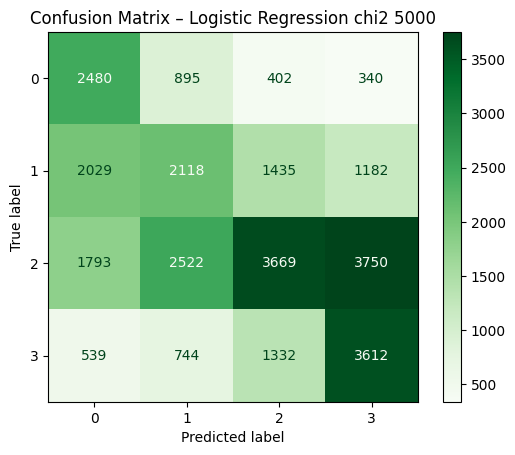

CV Naive Bayes (k=5000) F1 macro per fold: [0.32906962 0.33082873 0.32444657 0.32617286 0.3272123 ]
CV Naive Bayes (k=5000) mean=0.3275, std=0.0022

Evaluation Metrics Naive Bayes chi2 k = 5000
Naive Bayes Accuracy: 0.4519
Classification report:
               precision    recall  f1-score   support

           1       0.48      0.32      0.38      4117
           2       0.40      0.08      0.13      6764
           3       0.44      0.89      0.59     11734
           4       0.58      0.12      0.20      6227

    accuracy                           0.45     28842
   macro avg       0.48      0.35      0.33     28842
weighted avg       0.47      0.45      0.37     28842

Macro F1-score: 0.32579269500369507
Weighted F1-score: 0.36902095933470236


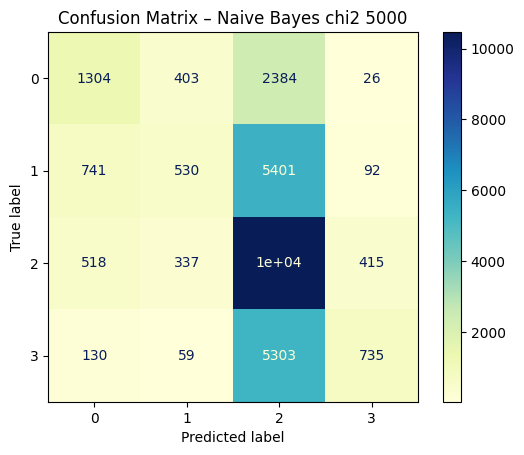

CV Decision Tree (k=5000) F1 macro per fold: [0.24186392 0.23839351 0.23399501 0.24680412 0.23943066]
CV Decision Tree (k=5000) mean=0.2401, std=0.0042

Evaluation Metrics Decision Tree chi2 k = 5000
Decision Tree Accuracy: 0.4028
Classification report:
               precision    recall  f1-score   support

           1       0.38      0.13      0.19      4117
           2       0.27      0.06      0.10      6764
           3       0.42      0.88      0.56     11734
           4       0.33      0.06      0.10      6227

    accuracy                           0.40     28842
   macro avg       0.35      0.28      0.24     28842
weighted avg       0.36      0.40      0.30     28842

Macro F1-score: 0.2392857878572087
Weighted F1-score: 0.3020570719749497


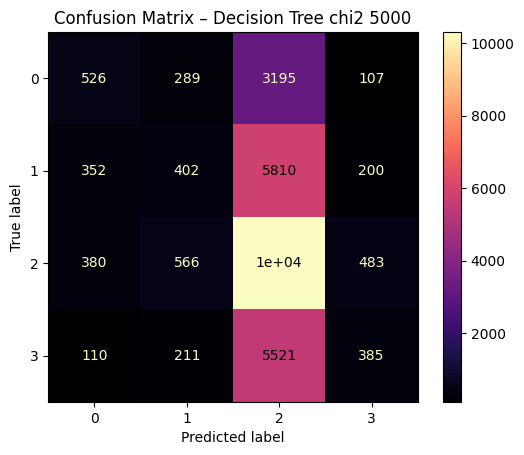

CV Random Forest (k=5000) F1 macro per fold: [0.29080947 0.29049387 0.28912442 0.28915849 0.28775247]
CV Random Forest (k=5000) mean=0.2895, std=0.0011

Evaluation Metrics Random Forest chi2 k = 5000
Random Forest Accuracy: 0.4375
Classification report:
               precision    recall  f1-score   support

           1       0.51      0.24      0.33      4117
           2       0.37      0.05      0.09      6764
           3       0.43      0.91      0.58     11734
           4       0.50      0.10      0.17      6227

    accuracy                           0.44     28842
   macro avg       0.45      0.32      0.29     28842
weighted avg       0.44      0.44      0.34     28842

Macro F1-score: 0.29192430058586727
Weighted F1-score: 0.3414233738461934


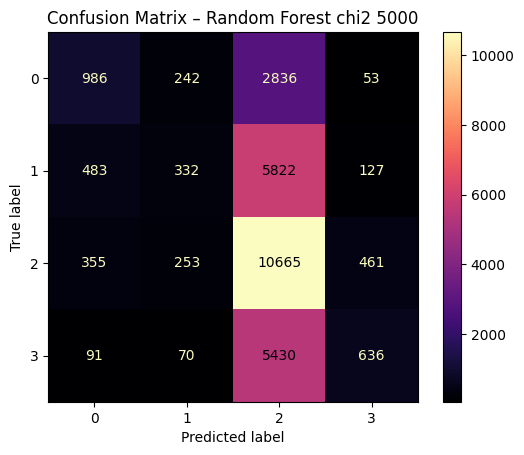

In [5]:
from sklearn.linear_model import LogisticRegression
from sklearn.naive_bayes import MultinomialNB
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.svm import LinearSVC
from sklearn.feature_selection import SelectKBest, chi2
from sklearn.pipeline import Pipeline
from sklearn.model_selection import StratifiedKFold, cross_val_score
from sklearn.metrics import (
    accuracy_score,
    f1_score,
    classification_report,
)
import random
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt

k_values = [5000]
skfold = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

models = {
    "Logistic Regression": LogisticRegression(
        max_iter=5000,
        n_jobs=-1,
        solver="saga",
        penalty="l1",
        class_weight="balanced"

    ),
    "Naive Bayes": MultinomialNB(),
    "Decision Tree": DecisionTreeClassifier(
        criterion="gini",
        max_depth=20,
        min_samples_leaf=5,
        random_state=42,
    ),
    "Random Forest": RandomForestClassifier(
        n_estimators=200,
        class_weight="balanced",
        max_depth=None,
        n_jobs=-1,
        random_state=42,
    )
}
def plot_confusion_matrices(model_name, y_test, y_pred, k_value):
  """
  Plots confusion matrices for Models
  """
  cmaps = [
    "Blues", "Greens", "Purples", "Oranges", "Reds",
    "viridis", "plasma", "inferno", "magma", "cividis",
    "YlGnBu", "YlOrRd", "PuBuGn", "GnBu", "BuPu",
  ]

  cmap_choice = random.choice(cmaps)

  cm = confusion_matrix(y_test, y_pred)
  disp = ConfusionMatrixDisplay(confusion_matrix=cm)
  disp.plot(cmap=cmap_choice)
  plt.title(f"Confusion Matrix – {model_name} chi2 {k_value}")
  plt.show()


def evaluate_and_report_model(
    model_name,
    model,
    k_value,
    y_train,
    y_test,
    skfold,
    X_train = X_train_text,
    X_test = X_test_text,
):
    tfidf_vectorizer = TfidfVectorizer(
        min_df=3,
        max_df=0.9,
        max_features=10000,
        ngram_range=(1, 2),
    )

    feature_selector = SelectKBest(score_func=chi2, k=k_value)

    pipeline = Pipeline(
        [
            ("tfidf", tfidf_vectorizer),
            ("chi2", feature_selector),
            ("clf", model),
        ]
    )

    cv_scores = cross_val_score(
        pipeline,
        X_train,
        y_train,
        cv=skfold,
        scoring="f1_macro",
        n_jobs=-1,
    )
    print(f"CV {model_name} (k={k_value}) F1 macro per fold: {cv_scores}")
    print(
        f"CV {model_name} (k={k_value}) "
        f"mean={cv_scores.mean():.4f}, std={cv_scores.std():.4f}"
    )

    pipeline.fit(X_train, y_train)
    y_pred = pipeline.predict(X_test)

    print(f"\nEvaluation Metrics {model_name} chi2 k = {k_value}")
    print(f"{model_name} Accuracy: {accuracy_score(y_test, y_pred):.4f}")
    print(
        "Classification report:\n",
        classification_report(y_test, y_pred, zero_division=0),
    )
    print(
        "Macro F1-score:",
        f1_score(y_test, y_pred, average="macro", zero_division=0),
    )
    print(
        "Weighted F1-score:",
        f1_score(y_test, y_pred, average="weighted", zero_division=0),
    )

    plot_confusion_matrices(model_name, y_test, y_pred, k_value)

for k_value in k_values:
    for model_name, model in models.items():
        evaluate_and_report_model(
            model_name,
            model,
            k_value,
            y_train,
            y_test,
            skfold,
            X_train = X_train_text,
            X_test = X_test_text,

        )


In [16]:
!pip install scipy
from scipy import sparse
from scipy.sparse import hstack
from sklearn.linear_model import LogisticRegression
from sklearn.svm import LinearSVC
from sklearn.preprocessing import StandardScaler
from sklearn.feature_selection import SelectKBest, chi2
from sklearn.pipeline import Pipeline

k_values = 2000
tfidf_vectorizer = TfidfVectorizer(
        min_df=3,
        max_df=0.9,
        max_features=10000,
        ngram_range=(1, 2),
    )
X_train_tfidf = tfidf_vectorizer.fit_transform(X_train_text)
X_test_tfidf = tfidf_vectorizer.transform(X_test_text)

feature_selector = SelectKBest(score_func=chi2, k=k_value)
X_train_tfidf_selected = feature_selector.fit_transform(X_train_tfidf, y_train)
X_test_tfidf_selected = feature_selector.transform(X_test_tfidf)

scaler = StandardScaler()
X_train_useful=scaler.fit_transform(X_train_useful.reshape(-1,1))

X_test_useful=scaler.transform(X_test_useful.reshape(-1,1))

# Create sparce matrix
X_train_useful_sparse = sparse.csr_matrix(X_train_useful)
X_test_useful_sparse = sparse.csr_matrix(X_test_useful)


# Create final marix
X_train_all = hstack((X_train_tfidf_selected, X_train_useful_sparse))
X_test_all = hstack((X_test_tfidf_selected, X_test_useful_sparse))

logistic_l1 = LogisticRegression(
        max_iter=5000,
        n_jobs=-1,
        solver="saga",
        penalty="l1",
        class_weight="balanced",
    )

logistic_l1.fit(X_train_all, y_train)
y_pred = logistic_l1.predict(X_test_all)

print(f"\nEvaluation Metrics Logistic Regression L1 k = 2000, combined")
print(f"{model_name} Accuracy: {accuracy_score(y_test, y_pred):.4f}")
print(
        "Classification report:\n",
        classification_report(y_test, y_pred, zero_division=0),
)
print(
        "Macro F1-score:",
        f1_score(y_test, y_pred, average="macro", zero_division=0),
    )
print(
        "Weighted F1-score:",
        f1_score(y_test, y_pred, average="weighted", zero_division=0),
    )




Evaluation Metrics Logistic Regression L1 k = 2000, combined
Random Forest Accuracy: 0.4135
Classification report:
               precision    recall  f1-score   support

           1       0.36      0.62      0.46      4117
           2       0.34      0.31      0.33      6764
           3       0.54      0.30      0.39     11734
           4       0.41      0.60      0.49      6227

    accuracy                           0.41     28842
   macro avg       0.41      0.46      0.41     28842
weighted avg       0.44      0.41      0.40     28842

Macro F1-score: 0.4141419798164137
Weighted F1-score: 0.4045644925459767
